## **Name:** Ajay  

### **Batch:** Data Science Batch 1st May  

### **Project Video:**  
[https://www.loom.com/share/c76a658b77244d56a4340bbc73e6a81a?sid=100bb8c3-ccc6-4aa7-a3fb-0a33d761047b](https://www.loom.com/share/c76a658b77244d56a4340bbc73e6a81a?sid=100bb8c3-ccc6-4aa7-a3fb-0a33d761047b)

### **GitHub Repository:**  
[https://github.com/ajaythakur958/ML-Project-Airbnb-Price-Prediction-and-Insights](https://github.com/ajaythakur958/ML-Project-Airbnb-Price-Prediction-and-Insights)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# import csv data file into pandas dataframe for processing the data cleaning

In [2]:
df = pd.read_csv("airbnb_data.csv")

In [3]:
df.head(1)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0


In [4]:
print("Shape of Matrix:", df.shape)
print('--'*50)
print(df.columns)

Shape of Matrix: (74111, 29)
----------------------------------------------------------------------------------------------------
Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')


# Removing useless columns that is useless for linear regression

In [5]:
cols_to_drop = ['id','name','thumbnail_url','description']
df = df.drop(columns=cols_to_drop)
df.head(1)

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,instant_bookable,last_review,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,...,f,18-07-2016,40.696524,-73.991617,Brooklyn Heights,2,100.0,11201,1.0,1.0


# Removing useless special characters from amenities column and couting the amenties_counts 

In [6]:
df['amenities'].unique()[:50]

array(['{"Wireless Internet","Air conditioning",Kitchen,Heating,"Family/kid friendly",Essentials,"Hair dryer",Iron,"translation missing: en.hosting_amenity_50"}',
       '{"Wireless Internet","Air conditioning",Kitchen,Heating,"Family/kid friendly",Washer,Dryer,"Smoke detector","Fire extinguisher",Essentials,Shampoo,Hangers,"Hair dryer",Iron,"translation missing: en.hosting_amenity_50"}',
       '{TV,"Cable TV","Wireless Internet","Air conditioning",Kitchen,Breakfast,"Buzzer/wireless intercom",Heating,"Family/kid friendly","Smoke detector","Carbon monoxide detector","Fire extinguisher",Essentials,Shampoo,Hangers,"Hair dryer",Iron,"Laptop friendly workspace","translation missing: en.hosting_amenity_50"}',
       '{TV,"Cable TV",Internet,"Wireless Internet",Kitchen,"Indoor fireplace","Buzzer/wireless intercom",Heating,Washer,Dryer,"Smoke detector","Carbon monoxide detector","First aid kit","Fire extinguisher",Essentials}',
       '{TV,Internet,"Wireless Internet","Air conditioning",Kitch

In [7]:
df['amenities'] = df['amenities'].apply(lambda x: x.replace("{","").replace("}","").replace('"','').split(","))
df['amenities'] = df['amenities'].apply(lambda x: [a.strip() for a in x if "translation missing" not in a])
df['amenities_count'] = df['amenities'].apply(len)
df.drop(columns=['amenities'], inplace=True)

# Checking nulls

In [8]:
df.isnull().sum().sort_values(ascending=False)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_has_profile_pic        188
host_identity_verified      188
host_since                  188
beds                        131
bedrooms                     91
bed_type                      0
accommodates                  0
room_type                     0
property_type                 0
log_price                     0
city                          0
cleaning_fee                  0
cancellation_policy           0
instant_bookable              0
latitude                      0
longitude                     0
number_of_reviews             0
amenities_count               0
dtype: int64

# Checking types of unique values in columns having null values 

In [9]:
numeric_cols = ['host_response_rate','review_scores_rating','first_review','last_review', 'bathrooms',
                'host_identity_verified','host_since','host_has_profile_pic','beds','bedrooms','zipcode']

for col in numeric_cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()}")
    print("Unique Values:", df[col].unique())
    print("-" * 80)

host_response_rate | Type: object | Nulls: 18299 | Filled: 55812
Unique Values: [nan '100%' '71%' '68%' '67%' '83%' '50%' '90%' '86%' '92%' '82%' '80%'
 '89%' '93%' '99%' '0%' '88%' '96%' '70%' '94%' '91%' '25%' '95%' '98%'
 '62%' '29%' '33%' '81%' '63%' '38%' '60%' '79%' '78%' '75%' '65%' '97%'
 '87%' '40%' '54%' '53%' '58%' '76%' '30%' '64%' '17%' '20%' '77%' '73%'
 '41%' '59%' '57%' '85%' '56%' '42%' '44%' '35%' '14%' '74%' '27%' '10%'
 '84%' '6%' '72%' '36%' '55%' '43%' '13%' '39%' '46%' '26%' '61%' '52%'
 '23%' '22%' '69%' '66%' '15%' '11%' '31%' '21%' '47%']
--------------------------------------------------------------------------------
review_scores_rating | Type: float64 | Nulls: 16722 | Filled: 57389
Unique Values: [100.  93.  92.  nan  40.  97.  99.  90.  89.  91.  88.  86.  72.  98.
  95.  96.  84.  80.  94.  87.  85.  70.  60.  75.  20.  76.  83.  82.
  78.  73.  55.  81.  67.  71.  77.  79.  47.  74.  68.  66.  63.  50.
  53.  65.  64.  27.  69.  30.  58.  35.  62.  49.  

# Handling null values

### Replacing string(num%) host_response_rate column to numeric num and replace null value with median

In [10]:
# Function to replace '%' to none and empty values replace by nan
def convert_percent(x):
    try:
        return float(str(x).replace('%',''))
    except:
        return np.nan
df['host_response_rate'] = df['host_response_rate'].apply(convert_percent)

#Calculate and Replace mull values with median
median_response = df['host_response_rate'].median()
df['host_response_rate'] = df['host_response_rate'].fillna(median_response)

### Numeric columns fills missing with median
### median because it's robust to outliers

In [11]:
numeric_cols = ['bathrooms', 'review_scores_rating', 'bedrooms', 'beds']
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

### Converting bool categorical data to 0/1 and replace null with mode

In [12]:
# Convert t/f to 1/0 and 
df['host_has_profile_pic'] = df['host_has_profile_pic'].map({'t':1,'f':0})
df['host_identity_verified'] = df['host_identity_verified'].map({'t':1,'f':0})
# Replaces with mode
df['host_has_profile_pic'] = df['host_has_profile_pic'].fillna(df['host_has_profile_pic'].mode()[0])
df['host_identity_verified'] = df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])

# Replace null with unknown in Text column for neigbours

In [13]:
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown').str.strip()

# Feature Engineering for date columns: converting to number of days since today

In [14]:
# Converts Date columns from object to datetime DataType
df['first_review'] = pd.to_datetime(df['first_review'], dayfirst=True, errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors='coerce')
df['host_since'] = pd.to_datetime(df['host_since'], dayfirst=True, errors='coerce')

# Fill missing date values with median 
df['first_review'] = df['first_review'].fillna(df['first_review'].median())
df['last_review'] = df['last_review'].fillna(df['last_review'].median())
df['host_since'] = df['host_since'].fillna(df['host_since'].median())

today = pd.Timestamp('today')

# Convert date columns into numeric features
df['host_days_since'] = (today - df['host_since']).dt.days
df['days_since_first_review'] = (today - df['first_review']).dt.days
df['days_since_last_review'] = (today - df['last_review']).dt.days

# Dropping the original date columns
df.drop(['first_review', 'last_review', 'host_since'], axis=1, inplace=True)

# Using regex we identify valid zipcode contains 4 or 5 num and remove extra string values from it 

In [15]:
df['zipcode'].unique()

array(['11201', '10019', '10027', '94117', '20009', '94131', '90292',
       '90015', '94121', '91748', '10009', '90254', '90277', '90804',
       '60622', '2127', '10002', '11226', '91401', '11212', '11411', nan,
       '11374', '90028', '10016', '11225', '90036', '90291', '90046',
       '90026', '94118', '11211', '10003', '60605', '90068', '90057',
       '10021', '20037', '11237', '11233', '60608', '10001', '94127',
       '91403', '11249', '10037', '10011', '10032', '91106', '94107',
       '20018', '90027', '91601', '20001', '10022', '91201', '90013',
       '11217', '91016', '10031', '10014', '11101', '94110', '94134',
       '91501', '10029', '90230', '90039', '11221', '20019', '60647',
       '20020', '10025', '10013', '10040', '91604', '10039', '10038',
       '60614', '20002', '11219', '11222', '90042', '94114', '20008',
       '11238', '20007', '11206', '91208', '11223', '2130', '2114',
       '94103', '91107', '11355', '11220', '91406', '10036', '10024',
       '90004', '1

In [16]:
import re

def clean_zipcode(x):
    x = str(x).strip()
    x = re.sub(r'\s+', '', x)
    match = re.findall(r'\d{4,5}', x)
    if match:
        return match[0]
    else:
        return 0  # replace invalid with 0

df['zipcode'] = df['zipcode'].apply(clean_zipcode).astype(int)

In [17]:
# Fill missing date values with mode in zipcode 
df['zipcode'] = df['zipcode'].fillna(df['zipcode'].mode()[0])
print(df['zipcode'].nunique())

650


In [18]:
df.isnull().sum()

log_price                  0
property_type              0
room_type                  0
accommodates               0
bathrooms                  0
bed_type                   0
cancellation_policy        0
cleaning_fee               0
city                       0
host_has_profile_pic       0
host_identity_verified     0
host_response_rate         0
instant_bookable           0
latitude                   0
longitude                  0
neighbourhood              0
number_of_reviews          0
review_scores_rating       0
zipcode                    0
bedrooms                   0
beds                       0
amenities_count            0
host_days_since            0
days_since_first_review    0
days_since_last_review     0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   log_price                74111 non-null  float64
 1   property_type            74111 non-null  object 
 2   room_type                74111 non-null  object 
 3   accommodates             74111 non-null  int64  
 4   bathrooms                74111 non-null  float64
 5   bed_type                 74111 non-null  object 
 6   cancellation_policy      74111 non-null  object 
 7   cleaning_fee             74111 non-null  bool   
 8   city                     74111 non-null  object 
 9   host_has_profile_pic     74111 non-null  float64
 10  host_identity_verified   74111 non-null  float64
 11  host_response_rate       74111 non-null  float64
 12  instant_bookable         74111 non-null  object 
 13  latitude                 74111 non-null  float64
 14  longitude             

# Select Only numeric Columns for outliers detection

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['log_price', 'accommodates', 'bathrooms', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'latitude', 'longitude',
       'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms',
       'beds', 'amenities_count', 'host_days_since', 'days_since_first_review',
       'days_since_last_review'],
      dtype='object')


## Outliers detection for numeric columns

In [21]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    percent_outliers = (len(outliers) / len(df[col])) * 100
    
    print(f"{col:<25} : {percent_outliers:6.2f}% outliers")

log_price                 :   2.07% outliers
accommodates              :   4.86% outliers
bathrooms                 :  21.34% outliers
host_has_profile_pic      :   0.30% outliers
host_identity_verified    :   0.00% outliers
host_response_rate        :  16.94% outliers
latitude                  :   0.00% outliers
longitude                 :   0.00% outliers
number_of_reviews         :  11.07% outliers
review_scores_rating      :   6.24% outliers
zipcode                   :   0.00% outliers
bedrooms                  :  32.70% outliers
beds                      :   7.67% outliers
amenities_count           :   1.84% outliers
host_days_since           :   0.25% outliers
days_since_first_review   :   7.40% outliers
days_since_last_review    :  10.84% outliers


# Beds, Bathrooms, and Bedrooms have the most outliers, so we’ll cap their extreme values at 1% to preserve 99% of the real data.

In [22]:
# prints unique values and types of the columns
cols = ['bedrooms', 'beds', 'bathrooms']
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:100])
    print('--'*50)

bedrooms | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 11
Unique Values: [ 1.  3.  2.  0.  4.  5.  6.  7.  8.  9. 10.]
----------------------------------------------------------------------------------------------------
beds | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 18
Unique Values: [ 1.  3.  2.  7.  4.  6.  5. 10.  8. 16.  9. 13. 12. 11. 14. 15.  0. 18.]
----------------------------------------------------------------------------------------------------
bathrooms | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 17
Unique Values: [1.  1.5 2.  2.5 3.  0.5 4.5 5.  0.  4.  3.5 5.5 7.5 6.  8.  7.  6.5]
----------------------------------------------------------------------------------------------------


In [23]:
cols = ['bedrooms', 'beds', 'bathrooms']
for col in cols:
    upper_limit = df[col].quantile(0.99)
    print(f"99th Percentile (Upper Limit) of {col}:", upper_limit)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# Converts these two columns to int since it doesn't have any float values
df['bedrooms'] = df['bedrooms'].astype(int)
df['beds'] = df['beds'].astype(int)

99th Percentile (Upper Limit) of bedrooms: 4.0
99th Percentile (Upper Limit) of beds: 6.0
99th Percentile (Upper Limit) of bathrooms: 3.5


## Distribution and BoxPlot after cap to 1% for cols 'bedrooms', 'beds', 'bathrooms'

Column 'bedrooms' unique values: [1 3 2 0 4]


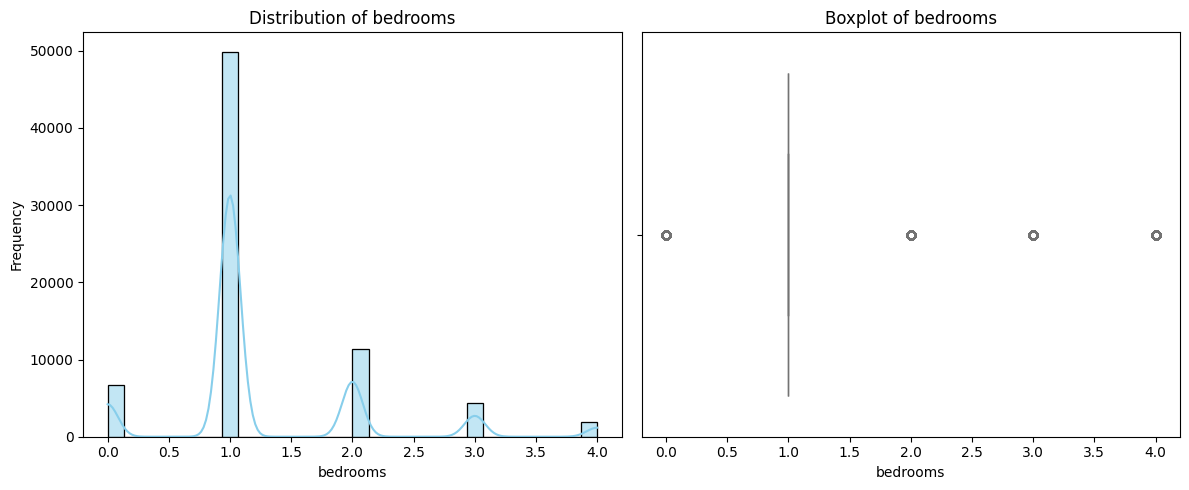

Column 'beds' unique values: [1 3 2 6 4 5 0]


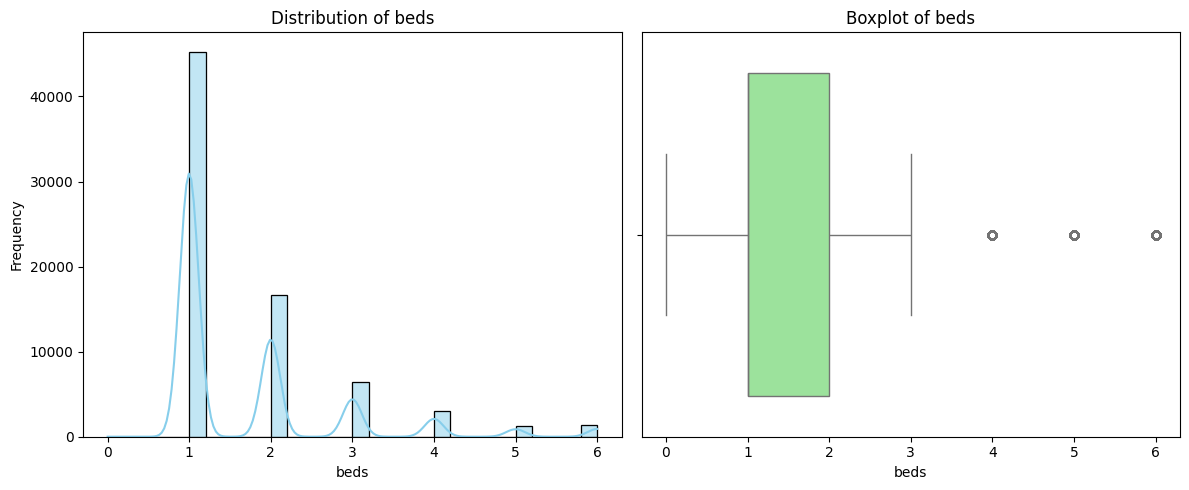

Column 'bathrooms' unique values: [1.  1.5 2.  2.5 3.  0.5 3.5 0. ]


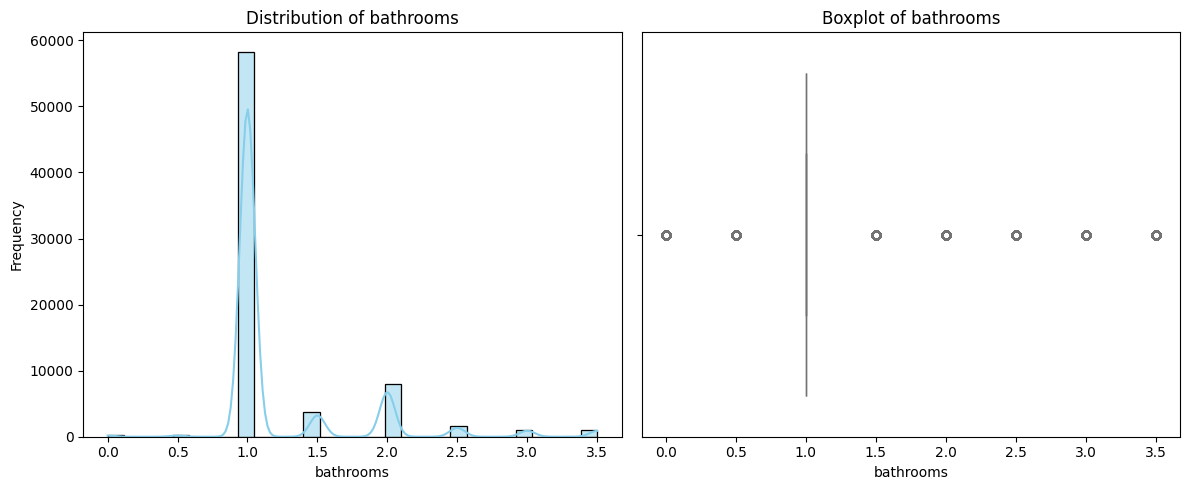

In [24]:
cols = ['bedrooms', 'beds', 'bathrooms']
for col in cols:
    print(f"Column '{col}' unique values:", df[col].unique()[:50])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

# Checking Unique values and Distribution plots of columns have big number values

In [25]:
# prints unique values and types of the columns
cols = ['number_of_reviews', 'days_since_last_review', 'days_since_first_review','host_days_since']
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:100])
    print('--'*50)

number_of_reviews | Type: int64 | Nulls: 0 | Filled: 74111 | Unique Count: 371
Unique Values: [  2   6  10   0   4   3  15   9 159  82  29  13  12  26   5  57  73  14
   1  40 248  46  17 138  11  44  34  85  18  31  30  19  25  22  23  28
   7  32 144  16  38 105  59  67  21 120   8  61  87 206  43 104  47  63
 186  36  27 167  48 102  51 126  81  58  72  68 107  79  98  39 187 123
  70  78  55  54  52  42  75 128  60  90 254 135  64  99 191  24  66 139
 125 129  74 318  33  35  37  20  93  83]
----------------------------------------------------------------------------------------------------
days_since_last_review | Type: int64 | Nulls: 0 | Filled: 74111 | Unique Count: 1371
Unique Values: [3376 2944 2953 3092 3188 2962 3099 3108 2943 3104 3256 3253 3090 3114
 3286 3172 3229 2952 3171 2945 3095 3868 3377 2957 3360 2981 3209 3102
 3255 3115 2939 3734 2950 3106 3101 3136 3257 2968 2941 3614 3096 3782
 3293 2935 3125 3089 3091 3100 3208 3709 3042 3132 3048 3368 2966 2942
 3168 3118 357

Column 'number_of_reviews' unique values: [  2   6  10   0   4   3  15   9 159  82]


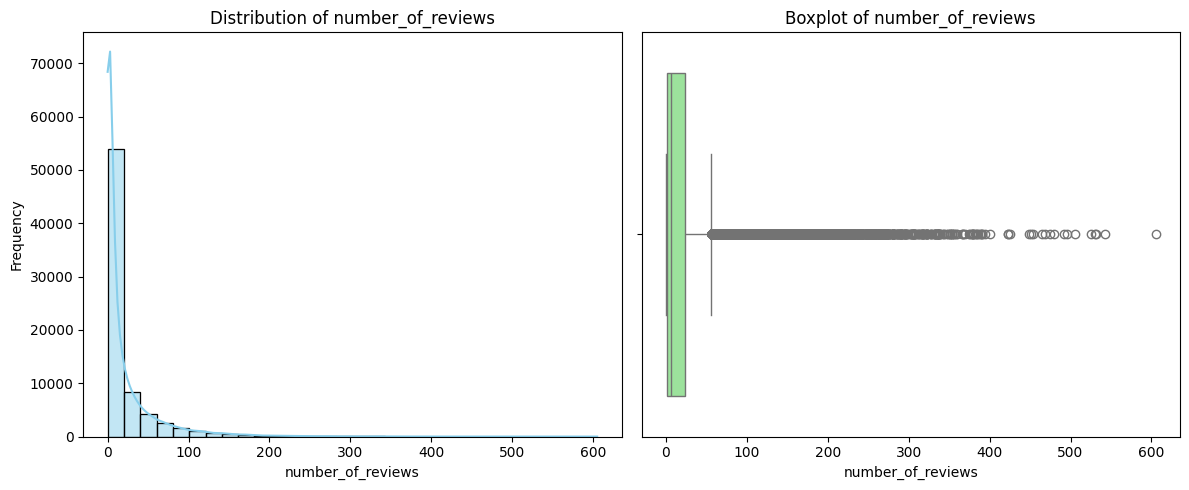

Column 'days_since_last_review' unique values: [3376 2944 2953 3092 3188 2962 3099 3108 2943 3104]


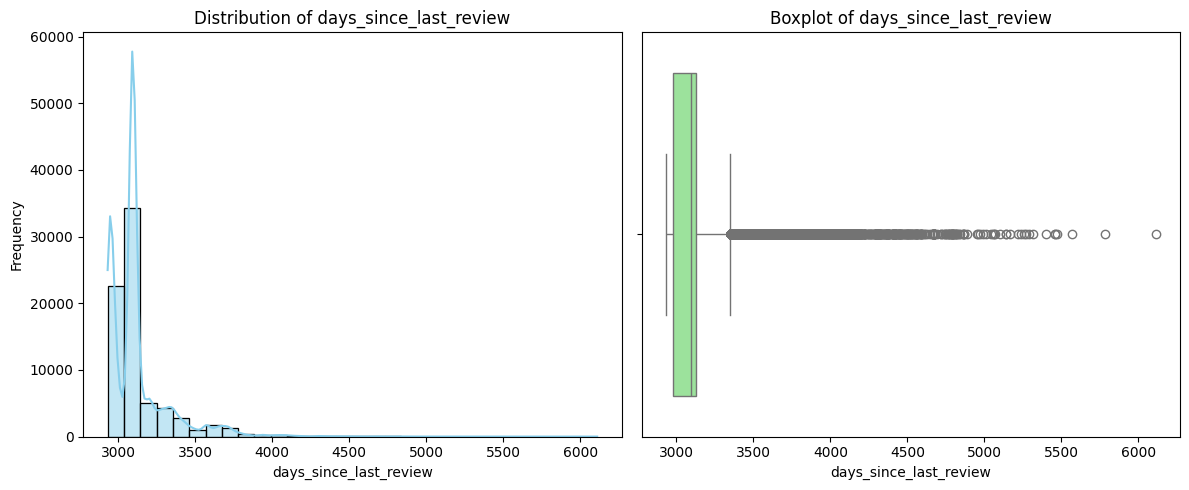

Column 'days_since_first_review' unique values: [3406 2993 3090 3430 3809 2971 3141 3225 3532 3117]


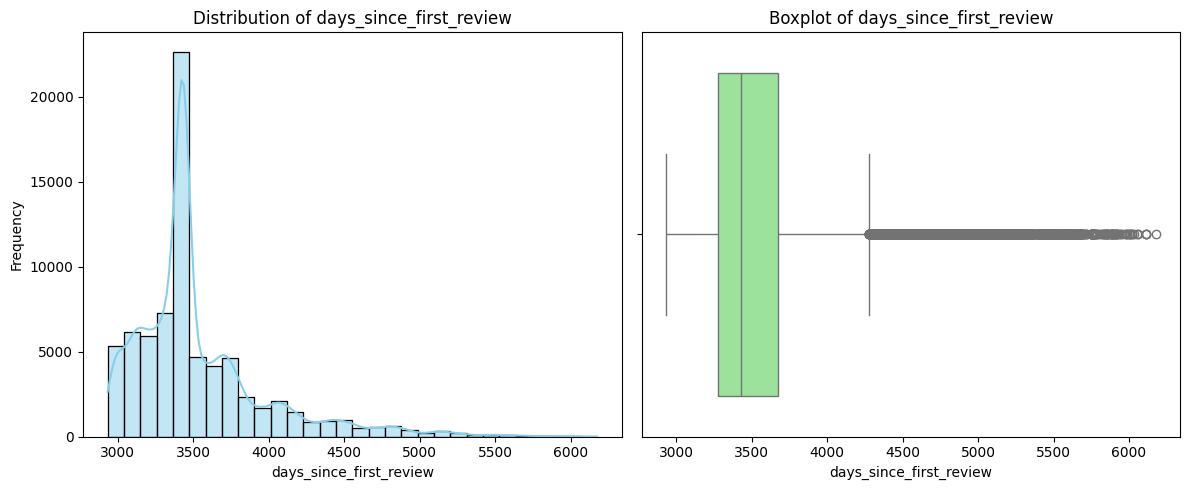

Column 'host_days_since' unique values: [4951 3040 3277 3832 3881 3052 3148 4533 3786 3139]


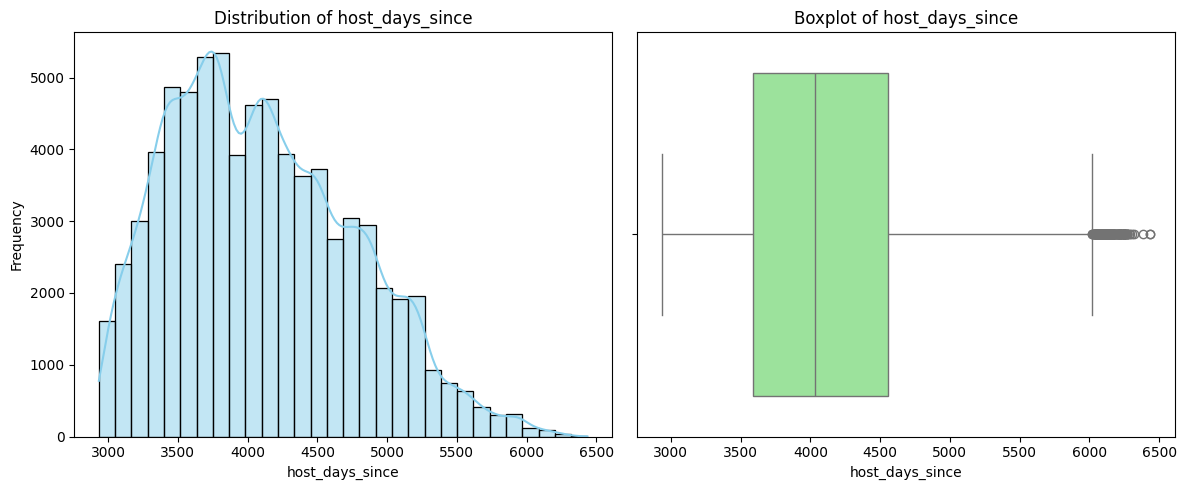

In [26]:
cols = ['number_of_reviews', 'days_since_last_review', 'days_since_first_review','host_days_since']
for col in cols:
    print(f"Column '{col}' unique values:", df[col].unique()[:10])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

# As these four columns have high values, we can use a logarithmic transformation to lessen the effect of big numbers and reduce skewness.

In [27]:
cols = ['number_of_reviews', 'days_since_last_review', 'days_since_first_review','host_days_since']
for col in cols:
    df[col] = np.log1p(df[col])

## Distribution and BoxPlot after applying logirithmic tranformation

Column 'number_of_reviews' unique values: [1.09861229 1.94591015 2.39789527 0.         1.60943791 1.38629436
 2.77258872 2.30258509 5.07517382 4.41884061]


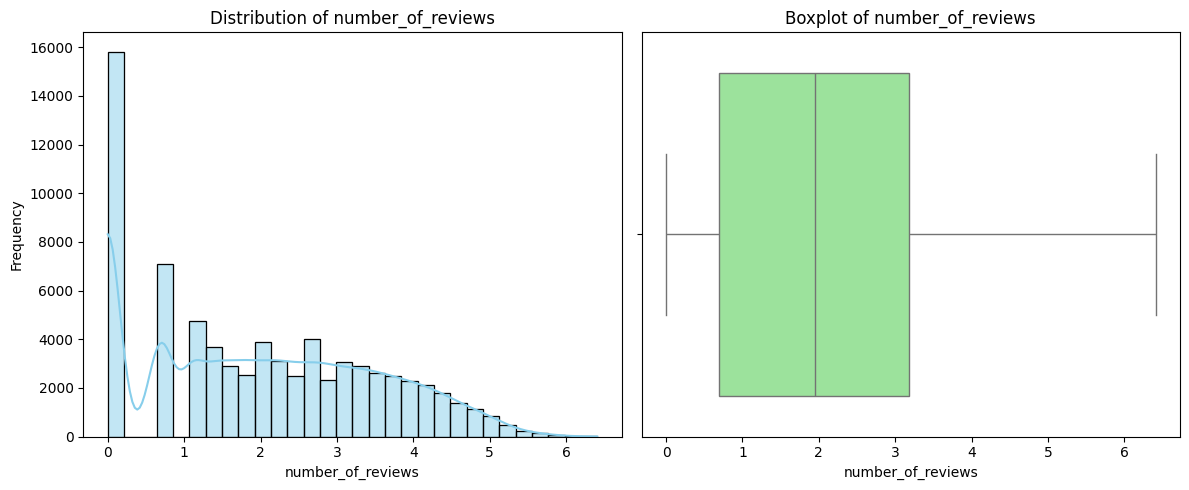

Column 'days_since_last_review' unique values: [8.12474302 7.9878641  7.99091546 8.03689677 8.06746267 7.99395755
 8.03915739 8.04205641 7.98752448 8.04076899]


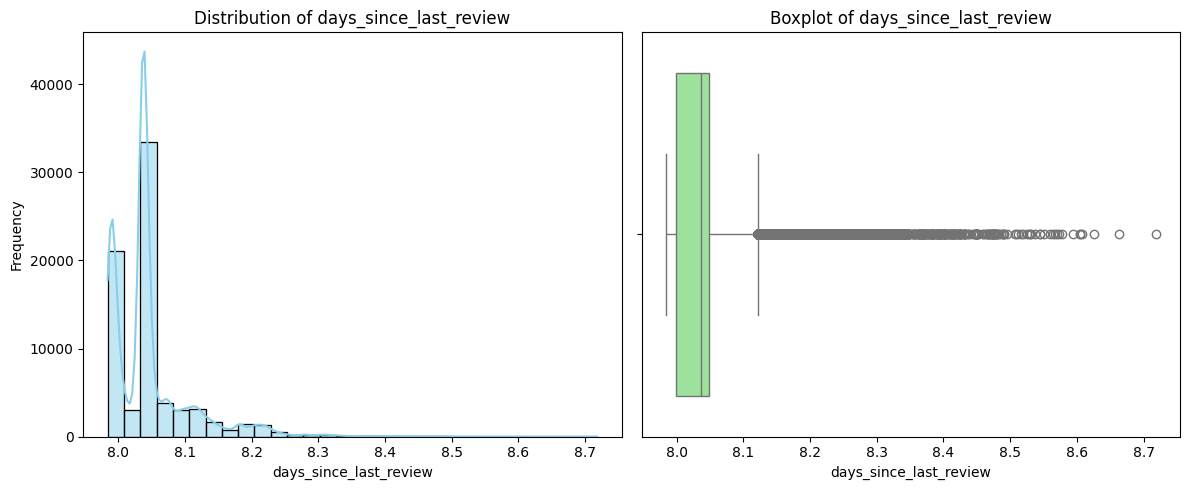

Column 'days_since_first_review' unique values: [8.13358742 8.00436556 8.03624994 8.14060704 8.24538447 7.99699041
 8.05261482 8.07899826 8.16990265 8.04494705]


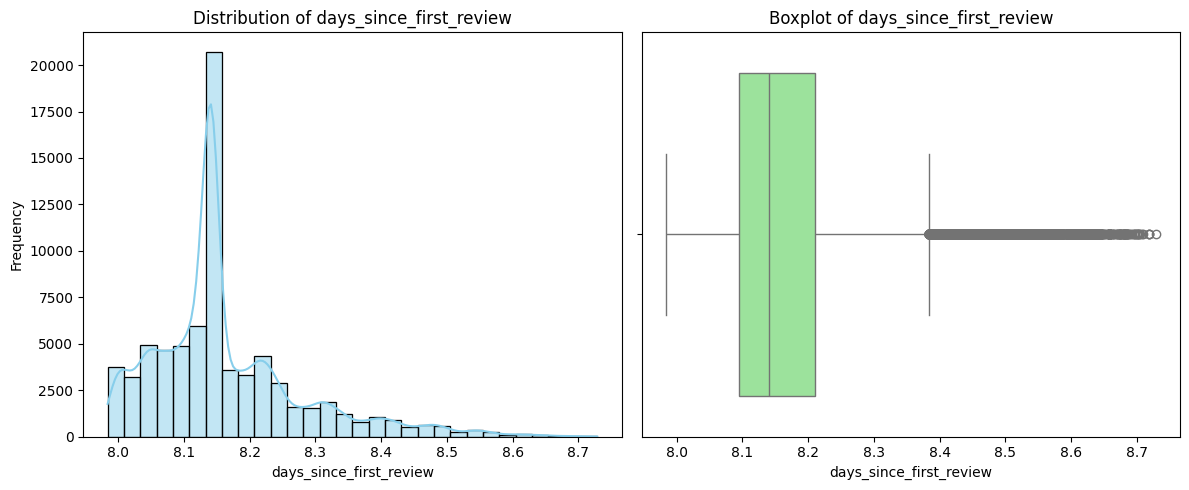

Column 'host_days_since' unique values: [8.50754681 8.01994169 8.09498876 8.25140307 8.26410576 8.02387999
 8.05484022 8.41935983 8.23932943 8.05197808]


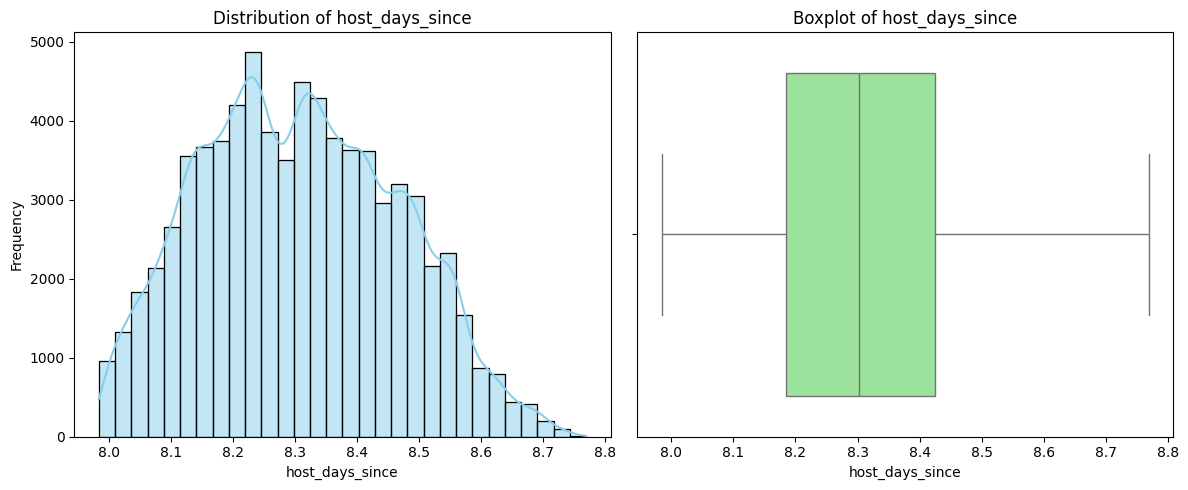

In [28]:
cols = ['number_of_reviews', 'days_since_last_review', 'days_since_first_review','host_days_since']
for col in cols:
    print(f"Column '{col}' unique values:", df[col].unique()[:10])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

# A few columns are of float datatype, but they can be converted to int since they don’t contain any decimal values.

In [29]:
print(df['review_scores_rating'].unique())
print(df['accommodates'].unique())
print(df['beds'].unique())

df['beds'] = df['beds'].astype(int)
df['accommodates'] = df['accommodates'].astype(int)
df['review_scores_rating'] = df['review_scores_rating'].astype(int)

[100.  93.  92.  96.  40.  97.  99.  90.  89.  91.  88.  86.  72.  98.
  95.  84.  80.  94.  87.  85.  70.  60.  75.  20.  76.  83.  82.  78.
  73.  55.  81.  67.  71.  77.  79.  47.  74.  68.  66.  63.  50.  53.
  65.  64.  27.  69.  30.  58.  35.  62.  49.  57.  54.  56.]
[ 3  7  5  4  2  6  8  1  9 10 16 11 12 14 13 15]
[1 3 2 6 4 5 0]


# Heatmap to see correlation which column effect most the target variable

In [30]:
cols = df.columns.tolist()
print("cols_name:", cols)

cols_name: ['log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms', 'beds', 'amenities_count', 'host_days_since', 'days_since_first_review', 'days_since_last_review']


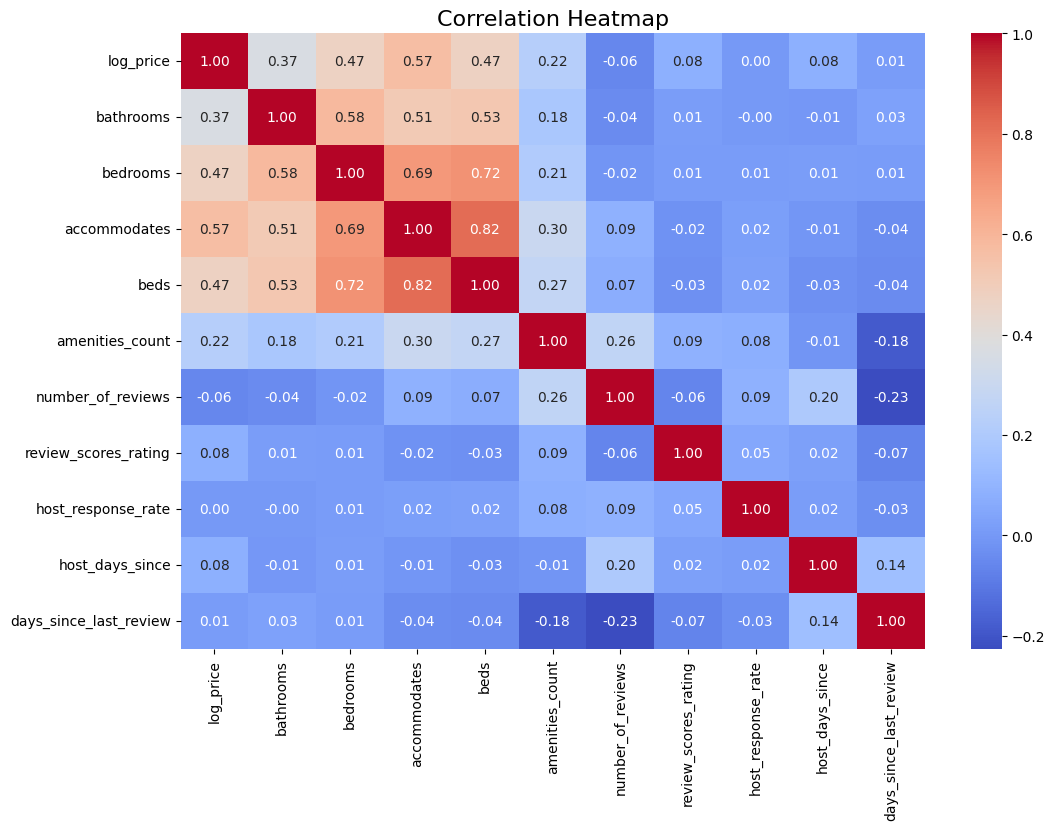

In [31]:
num_cols = [
    'log_price','bathrooms','bedrooms', 'accommodates','beds','amenities_count','number_of_reviews',
    'review_scores_rating','host_response_rate','host_days_since','days_since_last_review']

corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# 'Accommodates' has the strongest correlation with 'log_price' (0.57), meaning that as the number of accommodates increases, the price also tends to increase at a moderate level.

# Beds and Bedrooms have moderate correlations with 'log_price' (0.47), indicating that they also increase with price but have less impact than 'Accommodates'.

# The remaining columns are not highly correlated with 'log_price'.

In [32]:
cols = df.columns.tolist()
print("cols_name:", cols)
print("--"*50)
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:100])
    print("-" * 80)

cols_name: ['log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms', 'beds', 'amenities_count', 'host_days_since', 'days_since_first_review', 'days_since_last_review']
----------------------------------------------------------------------------------------------------
log_price | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 767
Unique Values: [5.01063529 5.12989872 4.97673374 6.62007321 4.74493213 4.44265126
 4.41884061 4.78749174 3.58351894 4.60517019 4.24849524 5.29831737
 4.95582706 4.09434456 4.31748811 4.59511985 4.88280192 4.38202663
 3.68887945 4.90527478 4.00733319 6.95654544 5.00394631 4.55387689
 5.19295685 4.65396035 3.8286414  5.22035583 4.48863637 4.35670883
 4.82831374 3.912023   4.6821312

# Columns to encode using ordinal encode and replace value like t/f to 1/0 checking types of value in it

In [33]:
cols = ['cancellation_policy','instant_bookable','host_has_profile_pic','host_identity_verified','cleaning_fee']
print("cols_name:", cols)
print("--"*50)
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:100])
    print("-" * 80)

cols_name: ['cancellation_policy', 'instant_bookable', 'host_has_profile_pic', 'host_identity_verified', 'cleaning_fee']
----------------------------------------------------------------------------------------------------
cancellation_policy | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 5
Unique Values: ['strict' 'moderate' 'flexible' 'super_strict_30' 'super_strict_60']
--------------------------------------------------------------------------------
instant_bookable | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 2
Unique Values: ['f' 't']
--------------------------------------------------------------------------------
host_has_profile_pic | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 2
Unique Values: [1. 0.]
--------------------------------------------------------------------------------
host_identity_verified | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 2
Unique Values: [1. 0.]
---------------------------------------------------------

# Applying ordinal Encoding for cancellation_policy having natural order

In [34]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['flexible', 'moderate', 'strict', 'super_strict_30', 'super_strict_60']])
df['cancellation_policy'] = encoder.fit_transform(df[['cancellation_policy']]).astype(int)

# convert category t/f, true/false, data to 1/0

In [35]:
df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0}).astype(int)
df['host_has_profile_pic'] = df['host_has_profile_pic'].astype(int)
df['host_identity_verified'] = df['host_identity_verified'].astype(int)
df['cleaning_fee'] = df['cleaning_fee'].astype(int)

In [36]:
cols = df.columns.tolist()
print("cols_name:", cols)
print("--"*50)
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:10])
    print("-" * 80)

cols_name: ['log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms', 'beds', 'amenities_count', 'host_days_since', 'days_since_first_review', 'days_since_last_review']
----------------------------------------------------------------------------------------------------
log_price | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 767
Unique Values: [5.01063529 5.12989872 4.97673374 6.62007321 4.74493213 4.44265126
 4.41884061 4.78749174 3.58351894 4.60517019]
--------------------------------------------------------------------------------
property_type | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 35
Unique Values: ['Apartment' 'House' 'Condominium' 'Loft' 'Townhouse' 'Hostel'
 'Guest suite' 'Bed 

# columns to one hot encode

In [37]:
cols = ['property_type','room_type','bed_type','city']
print("cols_name:", cols)
print("--"*50)
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:10])
    print("-" * 80)

cols_name: ['property_type', 'room_type', 'bed_type', 'city']
----------------------------------------------------------------------------------------------------
property_type | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 35
Unique Values: ['Apartment' 'House' 'Condominium' 'Loft' 'Townhouse' 'Hostel'
 'Guest suite' 'Bed & Breakfast' 'Bungalow' 'Guesthouse']
--------------------------------------------------------------------------------
room_type | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 3
Unique Values: ['Entire home/apt' 'Private room' 'Shared room']
--------------------------------------------------------------------------------
bed_type | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 5
Unique Values: ['Real Bed' 'Futon' 'Pull-out Sofa' 'Couch' 'Airbed']
--------------------------------------------------------------------------------
city | Type: object | Nulls: 0 | Filled: 74111 | Unique Count: 6
Unique Values: ['NYC' 'SF' 'DC' 'LA' 'Chicago'

# Applying One-Hot Encode for nominal — no natural order, multiple categories.

In [38]:
from sklearn.preprocessing import OneHotEncoder
cols_to_encode = ['property_type','room_type','bed_type','city']

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df[cols_to_encode])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols_to_encode))
encoded_df.index = df.index

df = df.drop(cols_to_encode, axis=1).join(encoded_df)

# Target encoding for zipcode and neigborhood sicne they contains 600+ unique values
# zipcode is numeric but actually categorical data so it will be good for targeting encoding 

## - Target encoding replaces categorical values with a numeric value that is derived from the target variable.
## - For regression usually it's the mean of the target for that particular category

In [39]:
for col in ['neighbourhood', 'zipcode']:
    target_mean = df.groupby(col)['log_price'].mean()
    df[col +'_encoded'] = df[col].map(target_mean)
    
    # Drop original column
    df.drop(col, axis=1, inplace=True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   log_price                         74111 non-null  float64
 1   accommodates                      74111 non-null  int64  
 2   bathrooms                         74111 non-null  float64
 3   cancellation_policy               74111 non-null  int64  
 4   cleaning_fee                      74111 non-null  int64  
 5   host_has_profile_pic              74111 non-null  int64  
 6   host_identity_verified            74111 non-null  int64  
 7   host_response_rate                74111 non-null  float64
 8   instant_bookable                  74111 non-null  int64  
 9   latitude                          74111 non-null  float64
 10  longitude                         74111 non-null  float64
 11  number_of_reviews                 74111 non-null  float64
 12  revi

# make variables for model train

In [41]:
x = df.drop(columns=['log_price'])
y = df['log_price']

# Standard Scaling for continuous numeric values columns

In [42]:
num_cols = ['latitude', 'longitude', 'review_scores_rating', 'amenities_count',
            'number_of_reviews', 'days_since_last_review',
            'host_response_rate', 'days_since_first_review',
            'host_days_since', 'beds', 'accommodates']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Data Splitting for training and test data

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Training the model and making prediction for test data to check accuracy of our data

In [44]:
my_lr = LinearRegression()
my_lr.fit(x_train, y_train)
y_pred = my_lr.predict(x_test)

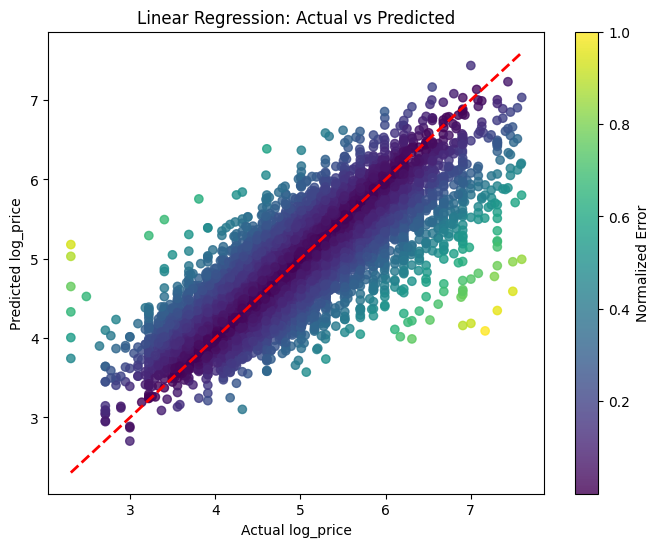

In [45]:
errors = np.abs(y_test - y_pred)
colors = errors / errors.max() 

plt.figure(figsize=(8,6))
scatter = plt.scatter(y_test, y_pred, c=colors, cmap='viridis', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) #draws perfet line linear regression
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Linear Regression: Actual vs Predicted')
plt.colorbar(scatter, label='Normalized Error')
plt.show()

In [54]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

Linear Regression Performance:
MSE: 0.1371
RMSE: 0.3702
MAE: 0.2671
R^2: 0.7332


## we get R^2 as 0.6734 means 67% of accurate prediction using linear regression model

# Now We will try another algorith that's XGBoost algorithm, which is robust to outliers because it is a tree-based method. It improves its accuracy each time a new tree is added, making the predictions progressively better.

## Import xgboost (Extreme Gradient Boosting)

In [48]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# create model
### n_estimators: How many trees to be made
### max_depth: max depth of an each tree
### learning_rate: controls the step size for updating predictions from each tree 
### subsample: how much data should be use for training the each tree
### colsample_bytree: the features each tree use

In [49]:
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.75,
    random_state=42
)

## Train the model

In [50]:
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Make Prediction and evaluate the results

In [51]:
y_pred = xgb_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

MSE: 0.1371
RMSE: 0.3702
MAE: 0.3003
R^2: 0.7332


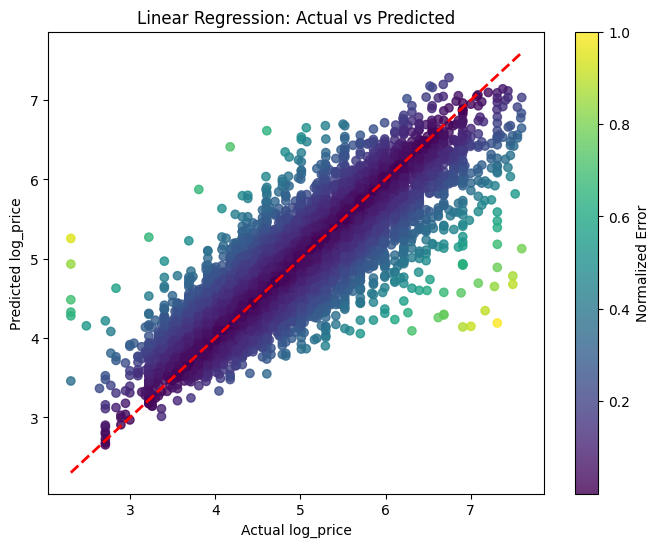

In [52]:
errors = np.abs(y_test - y_pred)
colors = errors / errors.max() 

plt.figure(figsize=(8,6))
scatter = plt.scatter(y_test, y_pred, c=colors, cmap='viridis', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Linear Regression: Actual vs Predicted')
plt.colorbar(scatter, label='Normalized Error')
plt.show()

## Tree-based model gives R² = 0.73, higher than linear regression R² = 0.673.
## Trees are robust to outliers, so predictions are less affected by extreme values.
## Linear regression is sensitive to outliers, which can reduce its accuracy.
## Hence, tree model performs better on this dataset.

In [59]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

                   Feature  Importance
52  room_type_Private room    0.395700
53   room_type_Shared room    0.179434
12                bedrooms    0.092090
62                 city_SF    0.032167
64         zipcode_encoded    0.026830
1                bathrooms    0.024223
0             accommodates    0.017712
61                city_NYC    0.016558
13                    beds    0.015661
63   neighbourhood_encoded    0.013662


### Business Insights
#### **Room type** is the most important factor affecting price.  
#### **Private** and **Shared rooms** have the highest influence on predictions.  
#### **Bedrooms**, **bathrooms**, and **accommodates** also play a major role — bigger listings = higher price.  
#### **Location factors** like **city** and **zipcode** have a moderate effect on price.  
#### Overall, both **property type** and **size** drive most of the price variation.

# Testing multiple values to find best values for xgboost

In [179]:
n_estimators_list = [400, 500, 600]
max_depth_list = [4, 6, 8]
learning_rate_list = [0.01, 0.05, 0.1]
subsample_list = [0.7, 0.8, 1.0]
colsample_bytree_list = [0.7, 0.8, 1.0]

best_r2 = -1
best_params = {}

for n in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            for subsample in subsample_list:
                for colsample in colsample_bytree_list:
                    model = xgb.XGBRegressor(
                        n_estimators=n,
                        max_depth=depth,
                        learning_rate=lr,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        random_state=42
                    )
                    model.fit(x_train, y_train)
                    preds = model.predict(x_test)
                    r2 = r2_score(y_test, preds)
                    
                    if r2 > best_r2:
                        best_r2 = r2
                        best_params = {
                            'n_estimators': n,
                            'max_depth': depth,
                            'learning_rate': lr,
                            'subsample': subsample,
                            'colsample_bytree': colsample
                        }

print("Best R²:", best_r2)
print("Best Parameters:", best_params)

Best R²: 0.7328306146969199
Best Parameters: {'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.7}


In [148]:
n_estimators_list = [600, 700, 800]
max_depth_list = [5, 6, 7]
learning_rate_list = [0.03, 0.05, 0.07]
subsample_list = [0.75, 0.8, 0.85]
colsample_bytree_list = [0.75, 0.8, 0.85]

best_r2 = -1
best_params = {}

for n in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            for subsample in subsample_list:
                for colsample in colsample_bytree_list:
                    model = xgb.XGBRegressor(
                        n_estimators=n,
                        max_depth=depth,
                        learning_rate=lr,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        random_state=42
                    )
                    model.fit(x_train, y_train)
                    preds = model.predict(x_test)
                    r2 = r2_score(y_test, preds)
                    
                    if r2 > best_r2:
                        best_r2 = r2
                        best_params = {
                            'n_estimators': n,
                            'max_depth': depth,
                            'learning_rate': lr,
                            'subsample': subsample,
                            'colsample_bytree': colsample
                        }

print("Best R²:", best_r2)
print("Best Parameters:", best_params)

Best R²: 0.7331558627245942
Best Parameters: {'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.75, 'colsample_bytree': 0.75}
